In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

In [2]:
data = pd.read_csv(PROJECT_ROOT / "data/raw/hvac_training_dataset.csv")
data.head()

,building_type,climate_zone,budget_level,area_sqft,floors,ceiling_height,occupancy,operating_hours,building_age,outdoor_temp,humidity,insulation,glass_ratio,recommended_hvac
0,Residential,Humid,Medium,1021.68,1.0,8.47,12.0,13.0,26.0,33.09,80.72,Average,Low,Split AC
1,Residential,Humid,Medium,2091.91,1.0,9.35,35.0,9.0,6.0,30.87,84.94,Good,Low,Split AC
2,Residential,Humid,Medium,2316.93,1.0,8.27,25.0,7.0,13.0,33.39,89.19,Average,Low,Split AC
3,Residential,Hot,NaN,2451.41,1.0,9.82,58.0,12.0,18.0,33.57,28.04,Average,Low,Split AC
4,Retail,Warm,Medium,119190.52,5.0,16.12,12825.0,14.0,0.0,30.76,51.36,Good,High,VRF


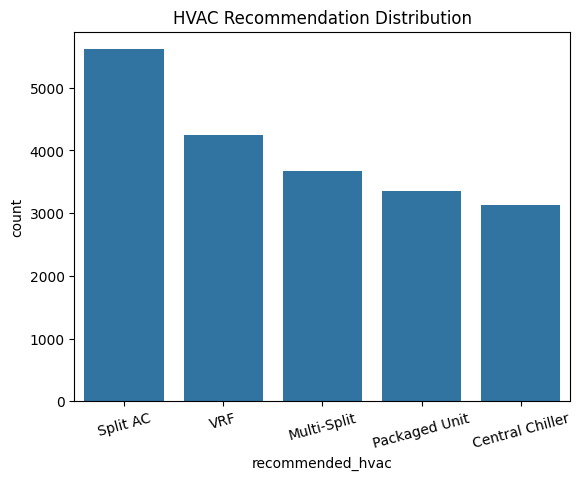

In [3]:
sns.countplot(
    data=data,
    x="recommended_hvac",
    order=data["recommended_hvac"].value_counts().index
)

plt.title("HVAC Recommendation Distribution")
plt.xticks(rotation=15)
plt.show()

In [4]:
print(
    data["recommended_hvac"]
    .value_counts(normalize=True) * 100
)

recommended_hvac
Split AC           28.065
VRF                21.210
Multi-Split        18.340
Packaged Unit      16.755
Central Chiller    15.630
Name: proportion, dtype: float64


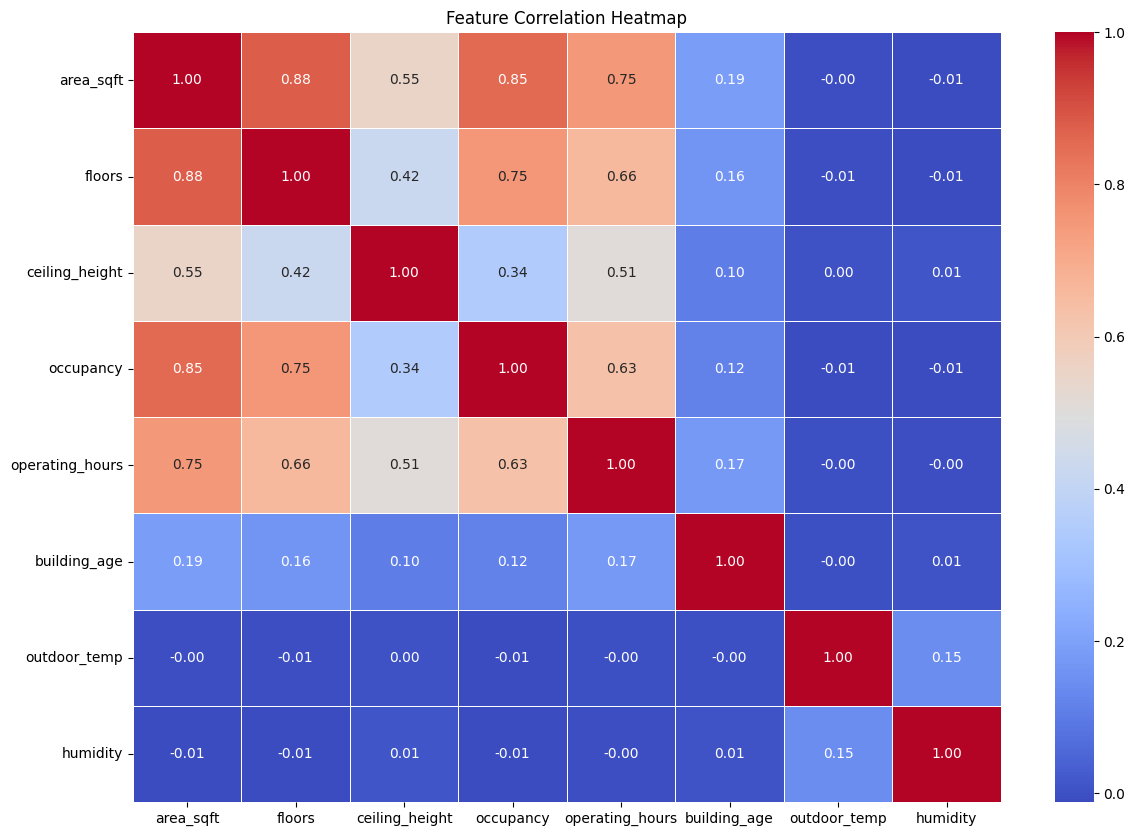

In [5]:
numeric_df = data.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
corr_pairs = corr.unstack()

corr_pairs = corr_pairs.sort_values(
    key=lambda x: abs(x),
    ascending=False
)

# Remove self correlations
corr_pairs = corr_pairs[corr_pairs != 1]

display(corr_pairs.head(20))

floors           area_sqft          0.881305
area_sqft        floors             0.881305
                 occupancy          0.854387
occupancy        area_sqft          0.854387
                 floors             0.752343
floors           occupancy          0.752343
area_sqft        operating_hours    0.749307
operating_hours  area_sqft          0.749307
                 floors             0.657140
floors           operating_hours    0.657140
occupancy        operating_hours    0.630409
operating_hours  occupancy          0.630409
ceiling_height   area_sqft          0.549553
area_sqft        ceiling_height     0.549553
operating_hours  ceiling_height     0.507087
ceiling_height   operating_hours    0.507087
floors           ceiling_height     0.424780
ceiling_height   floors             0.424780
occupancy        ceiling_height     0.344209
ceiling_height   occupancy          0.344209
dtype: float64

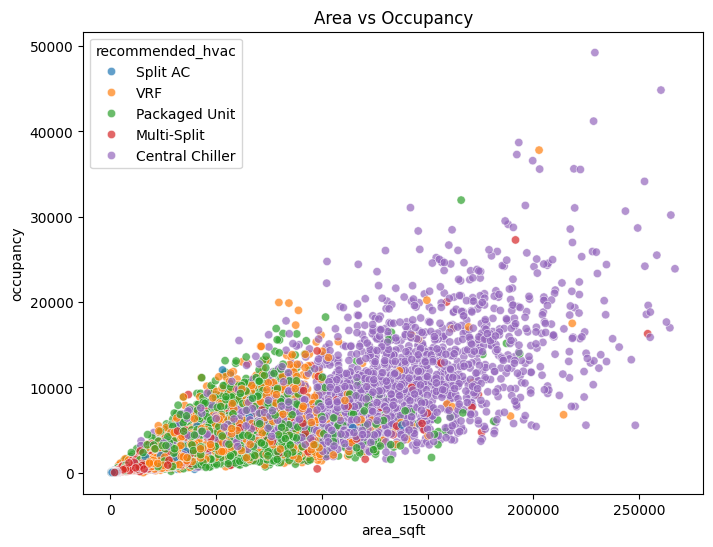

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=data,
    x="area_sqft",
    y="occupancy",
    hue="recommended_hvac",
    alpha=0.7
)

plt.title("Area vs Occupancy")
plt.show()